In [3]:
import pandas as pd
# import matplotlib.pyplot as plt
import numpy as np
# import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import explained_variance_score, r2_score, mean_absolute_error

In [4]:
df=pd.read_table('Fig1c.txt')
df.head()

,Accession_ID,Name,Country,Latitude,Longitude,CS_number,material,material_Country,Mg25,bio1,...,ph,CN,CEC,CaCO3,N,P,K,Mg,PC1,PC2
0,8241,Liarum,Sweden,55.9473,13.8210,CS77038,leaf,Sweden_leaf,6425.217028,6.800000,...,5.099498,16.017828,11.404053,8.995235,2.903223,34.881931,99.043198,37,-0.019888,-0.023376
1,6203,TDr-18,Sweden,55.7714,14.1208,CS77350,leaf,Sweden_leaf,6106.090545,7.400000,...,5.306688,16.933012,11.273796,11.339157,2.775039,43.916851,128.464050,40,-0.010401,-0.032897
2,5984,DraIV 6-13,Czech Republic,49.4112,16.2815,CS76822,leaf,Czech Republic_leaf,5937.667641,7.395833,...,5.724783,10.382457,11.531424,0.000000,2.134119,38.884171,205.518021,47,-0.048688,-0.004639
3,9399,Hamm-1,Sweden,55.4234,13.9905,CS76910,leaf,Sweden_leaf,5936.194976,7.937500,...,6.321225,11.384063,13.246228,10.353964,2.153087,56.946087,138.103867,39,-0.010179,-0.026704
4,8420,Kelsterbach-4,GER,50.0667,8.5333,CS76525,leaf,GER_leaf,5842.619693,10.337500,...,6.733436,13.335432,11.836184,54.417881,1.570549,32.795654,158.965622,43,-0.028367,0.003936


In [5]:
df=df.rename(columns={'coarse_frag':'coarse frag',
                   'bulk_density':'bulk density',
                   'CaCO3':'CaCO$_3$',
                     'ph':'pH',
                     'ai':'AI',
                     'awc':'AWC'})

In [6]:
df=df.select_dtypes(include='number')
df=df.drop(columns=['Accession_ID','Latitude','Longitude'])
df.head()

,Mg25,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,...,pH,CN,CEC,CaCO$_3$,N,P,K,Mg,PC1,PC2
0,6425.217028,6.800000,7.100000,29.831934,632.671082,20.400000,-3.4,23.799999,3.716667,5.483333,...,5.099498,16.017828,11.404053,8.995235,2.903223,34.881931,99.043198,37,-0.019888,-0.023376
1,6106.090545,7.400000,6.966667,29.645391,620.901123,21.000000,-2.5,23.500000,4.400000,2.383333,...,5.306688,16.933012,11.273796,11.339157,2.775039,43.916851,128.464050,40,-0.010401,-0.032897
2,5937.667641,7.395833,8.241667,30.079075,733.808411,22.500000,-4.9,27.400000,16.350000,-0.300000,...,5.724783,10.382457,11.531424,0.000000,2.134119,38.884171,205.518021,47,-0.048688,-0.004639
3,5936.194976,7.937500,6.741666,28.566383,631.276184,21.299999,-2.3,23.599998,8.766666,2.783333,...,6.321225,11.384063,13.246228,10.353964,2.153087,56.946087,138.103867,39,-0.010179,-0.026704
4,5842.619693,10.337500,8.458333,32.532051,672.647827,25.100000,-0.9,26.000000,17.166666,6.133333,...,6.733436,13.335432,11.836184,54.417881,1.570549,32.795654,158.965622,43,-0.028367,0.003936


In [630]:
df.describe()

,Mg25,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,...,pH,CN,CEC,CaCO$_3$,N,P,K,Mg,PC1,PC2
count,677.000000,677.000000,677.000000,677.000000,677.000000,677.000000,677.000000,677.000000,677.000000,677.000000,...,677.000000,677.000000,677.000000,677.000000,677.000000,677.000000,677.000000,677.000000,677.000000,677.000000
mean,4812.292404,9.718870,8.830945,33.829289,641.753001,24.375775,-1.733087,26.108863,10.805539,8.967848,...,6.198841,13.439422,15.327671,45.660225,2.206964,29.215190,202.134850,41.152142,0.000077,-0.000323
std,413.373057,3.016575,1.726936,4.301438,96.288938,3.829206,3.429031,3.656151,4.871708,8.484160,...,0.837301,3.687961,5.656161,59.434970,0.848656,12.280371,92.446700,9.335094,0.038330,0.038361
min,3589.943197,2.279167,3.850000,21.432650,342.829956,15.600000,-11.800000,12.900001,-2.666667,-3.533333,...,4.223059,7.471889,4.631545,0.000000,0.771269,0.641177,51.603909,14.000000,-0.057241,-0.133015
25%,4538.509111,7.637500,7.575000,30.344204,595.848633,21.400000,-3.300000,23.799999,7.300000,1.983333,...,5.724783,10.954319,11.254009,4.326532,1.638144,19.856781,142.913956,35.000000,-0.025562,-0.017278
50%,4832.643155,9.304167,8.666666,33.717949,644.262573,23.299999,-2.200000,26.299999,10.283334,5.383333,...,6.304936,12.611717,13.954475,25.370443,1.996375,28.193222,183.428604,41.000000,-0.011988,0.006790
75%,5096.468481,11.283334,9.858334,37.354309,701.217529,27.000000,0.500000,28.900000,15.333333,18.166666,...,6.765656,14.365889,18.195480,65.057213,2.615070,37.652962,236.647171,47.000000,0.012852,0.026596
max,6425.217028,18.591667,14.258333,45.817726,885.960754,35.700001,7.800000,34.700001,20.616667,26.000000,...,8.173202,29.304379,38.042904,414.742584,6.656757,73.434975,840.274902,65.000000,0.132906,0.063175


/Users/tergemina/opt/anaconda3/lib/python3.8/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:xlabel='Mg25'>

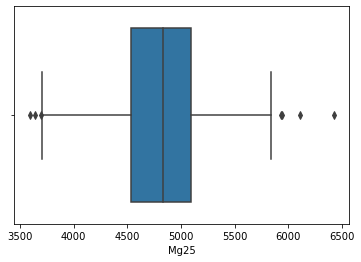

In [573]:
sns.boxplot(df['Mg25'])

In [607]:
from scipy import stats
# df=df[(np.abs(stats.zscore(df)) < 3).all(axis=1)]
df=df[np.abs(stats.zscore(df['Mg25'])) < 3]

In [631]:
X=df.drop(columns=['Mg25'])
Y=df['Mg25']

In [632]:
sc = StandardScaler()
X_scaled = sc.fit_transform(X)
print(X_train[0,:])

[ 0.80163994  1.17239711  0.14410198  1.3866493   1.25033559 -0.15941359
  1.48298783  1.04610518  1.4501644   1.3088924   0.12212628 -0.9602223
 -1.11941328 -0.32012641 -0.78883309 -1.11669244 -0.38545415 -0.70291078
 -0.68513345 -1.35349056  0.69810743 -0.98725576  0.30397074  1.19107621
  0.24658649  0.39093452  0.02554313 -0.18584781  0.77786817 -0.10394595
  1.83489983  0.72049355 -1.40746764 -1.53356961 -0.43439828 -0.23051202
 -0.4889953   0.3987208 ]


## Multiple linear regression

In [610]:
from sklearn.linear_model import LinearRegression
lr_model=LinearRegression()
lr_model.fit(X, Y)
Y_pred=lr_model.predict(X)
mae = mean_absolute_error(Y, Y_pred)
mse = mean_squared_error(Y, Y_pred)
r2 = r2_score(Y, Y_pred)
print('Mean Absolute Error:', round(mae, 2))
print('Mean Squared Error:', round(mse, 2))
print('R-squared scores:', round(r2, 2))

Mean Absolute Error: 275.15
Mean Squared Error: 122554.11
R-squared scores: 0.26


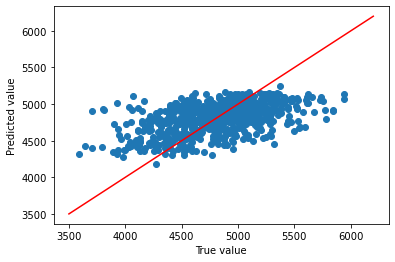

In [611]:
plt.scatter(Y, lr_model.predict(X))
x=np.linspace(3500,6200,500)
plt.plot(x, x, 'r-')
plt.xlabel('True value')
plt.ylabel('Predicted value')
plt.show()

## Support vector regression

In [614]:
from sklearn.svm import SVR
svr_model = SVR()
svr_model.fit(X, Y)
Y_pred=svr_model.predict(X)
mae = mean_absolute_error(Y, Y_pred)
mse = mean_squared_error(Y, Y_pred)
r2 = r2_score(Y, Y_pred)
print('Mean Absolute Error:', round(mae, 2))
print('Mean Squared Error:', round(mse, 2))
print('R-squared scores:', round(r2, 2))

Mean Absolute Error: 321.3
Mean Squared Error: 161583.24
R-squared scores: 0.02


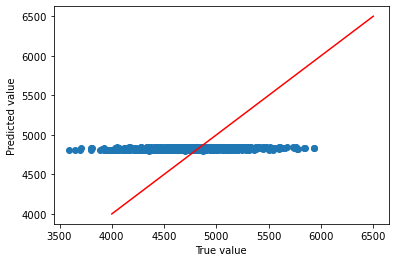

In [615]:
plt.scatter(Y,svr_model.predict(X))
x=np.linspace(4000,6500,500)
plt.plot(x, x, 'r-')
plt.xlabel('True value')
plt.ylabel('Predicted value')
plt.show()

## Decision tree

In [616]:
from sklearn.tree import DecisionTreeRegressor
tree_model= DecisionTreeRegressor()
tree_model.fit(X, Y)
Y_pred=tree_model.predict(X)
mae = mean_absolute_error(Y, Y_pred)
mse = mean_squared_error(Y, Y_pred)
r2 = r2_score(Y, Y_pred)
print('Mean Absolute Error:', round(mae, 2))
print('Mean Squared Error:', round(mse, 2))
print('R-squared scores:', round(r2, 2))


Mean Absolute Error: 0.0
Mean Squared Error: 0.0
R-squared scores: 1.0


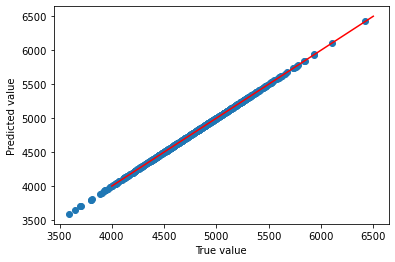

In [258]:
plt.scatter(Y,tree_model.predict(X))
x=np.linspace(4000,6500,500)
plt.plot(x, x, 'r-')
plt.xlabel('True value')
plt.ylabel('Predicted value')
plt.show()

In [261]:
from sklearn.preprocessing import PolynomialFeatures
poly_reg = PolynomialFeatures(degree = 4)
X_poly = poly_reg.fit_transform(X)
lin_reg_2 = LinearRegression()
lin_reg_2.fit(X_poly, Y)
Y_pred=lin_reg_2.predict(poly_reg.fit_transform(X))
mae = mean_absolute_error(Y, Y_pred)
mse = mean_squared_error(Y, Y_pred)
r2 = r2_score(Y, Y_pred)
print('Mean Absolute Error:', round(mae, 2))
print('Mean Squared Error:', round(mse, 2))
print('R-squared scores:', round(r2, 2))

Mean Absolute Error: 19.25
Mean Squared Error: 4870.3
R-squared scores: 0.97


## Random forest regression

#### Without cross validation

In [619]:
from sklearn.ensemble import RandomForestRegressor
forest_model= RandomForestRegressor()
forest_model.fit(X, Y)
Y_pred=forest_model.predict(X)
mae = mean_absolute_error(Y, Y_pred)
mse = mean_squared_error(Y, Y_pred)
r2 = r2_score(Y, Y_pred)
print('Mean Absolute Error:', round(mae, 2))
print('Mean Squared Error:', round(mse, 2))
print('R-squared scores:', round(r2, 2))

Mean Absolute Error: 109.16
Mean Squared Error: 19623.71
R-squared scores: 0.88


In [620]:
forest_model.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'criterion': 'mse',
 'max_depth': None,
 'max_features': 'auto',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_impurity_split': None,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

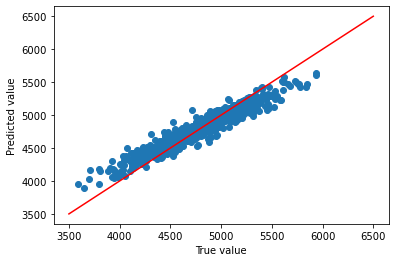

In [623]:
plt.scatter(Y,forest_model.predict(X))
x=np.linspace(3500,6500,500)
plt.plot(x, x, 'r-')
plt.xlabel('True value')
plt.ylabel('Predicted value')
plt.show()

#### With cross validation

In [624]:
from sklearn.model_selection import GridSearchCV
parameters={'max_depth':[5,10],
           'max_leaf_nodes':[10,20],
           'n_estimators':[100,200]}
forest_model= RandomForestRegressor()
forest_model_cv=GridSearchCV(forest_model,parameters,cv=10)
forest_model_cv.fit(X,Y)

GridSearchCV(cv=10, estimator=RandomForestRegressor(),
             param_grid={'max_depth': [5, 10], 'max_leaf_nodes': [10, 20],
                         'n_estimators': [100, 200]})

In [625]:
print(forest_model_cv.best_params_)
print(forest_model_cv.best_score_)
print('R2:',round(r2_score(Y,forest_model_cv.predict(X)),2))

{'max_depth': 5, 'max_leaf_nodes': 10, 'n_estimators': 200}
-51.40514890501612
R2: 0.37


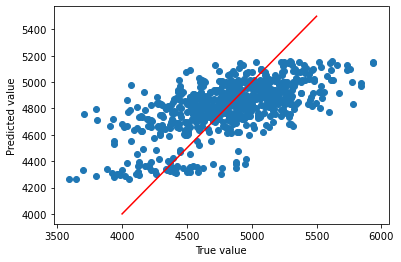

In [626]:
plt.scatter(Y,forest_model_cv.predict(X))
x=np.linspace(4000,5500,500)
plt.plot(x, x, 'r-')
plt.xlabel('True value')
plt.ylabel('Predicted value')
plt.show()

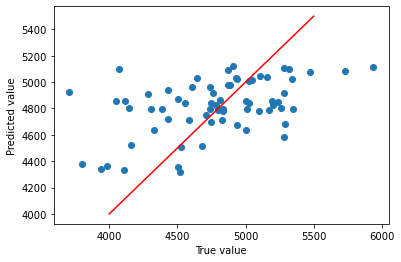

In [350]:
plt.scatter(Y_test,forest_model_cv.predict(X_test))
x=np.linspace(4000,5500,500)
plt.plot(x, x, 'r-')
plt.xlabel('True value')
plt.ylabel('Predicted value')
plt.show()

# With training testing sets

In [7]:
X=df.drop(columns=['Mg25'])
Y=df['Mg25']

In [8]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.20,random_state = 0)

In [9]:
print(X_test.head())

          bio1      bio2       bio3        bio4       bio5  bio6       bio7  \
279  12.691667  9.650000  35.347984  632.763916  28.100000   0.8  27.300001   
144   7.900000  6.650000  35.945946  441.495392  18.500000   0.0  18.500000   
440  10.154167  9.958333  39.674637  554.180237  24.500000  -0.6  25.100000   
390  10.170834  7.791667  38.008129  472.076935  22.000000   1.5  20.500000   
588  10.333333  7.633333  34.077381  548.329407  23.200001   0.8  22.400002   

          bio8       bio9      bio10  ...        pH         CN        CEC  \
279  13.166666  20.816666  20.816666  ...  6.541297  12.033339  19.606127   
144   3.700000   9.400000  13.566667  ...  5.437558  12.148521  13.800424   
440   7.116667  17.233334  17.233334  ...  5.870054  13.504377  11.921408   
390   7.750000   6.483333  16.266666  ...  5.772104  13.715875  13.949490   
588   7.300000   6.383333  17.166666  ...  6.346672   9.499113  11.381659   

       CaCO$_3$         N          P           K  Mg       PC1

In [10]:
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)
print(X_train[0,:])

[ 0.54137583  0.64237734 -0.16804672  1.23818018  0.74152495 -0.3037438
  1.05572152  1.99917947 -0.80089505  0.98134268 -0.04800629  0.33675192
  0.39925291 -0.17089518  0.31291569  0.21549357 -0.0836095   1.18216955
 -0.72789377 -2.11050277  0.16584426 -0.00270289  0.68752923 -0.25228495
  2.28821844  1.56765712 -1.29872929  0.53788903  0.70951934 -0.18022892
  1.71078734  0.72143196 -0.0993969  -0.97727896 -0.29022226  1.26702629
 -0.33556907 -0.48207846]


In [594]:
Y.describe()

count     675.000000
mean     4807.986148
std       406.229474
min      3589.943197
25%      4536.948378
50%      4831.457455
75%      5091.920412
max      5937.667641
Name: Mg25, dtype: float64

## Multiple linear regression

In [11]:
from sklearn.linear_model import LinearRegression
lr_model=LinearRegression()
lr_model.fit(X_train, Y_train)
Y_pred=lr_model.predict(X_test)
mae = mean_absolute_error(Y_test, Y_pred)
mse = mean_squared_error(Y_test, Y_pred)
r2 = r2_score(Y_test, Y_pred)
print('Mean Absolute Error:', round(mae, 2))
print('Mean Squared Error:', round(mse, 2))
print('R-squared scores:', round(r2, 2))

Mean Absolute Error: 306.86
Mean Squared Error: 149061.89
R-squared scores: 0.2


In [12]:
r2_score(Y_train,lr_model.predict(X_train))

0.26214819782281773

## Support vector regression

In [534]:
from sklearn.svm import SVR
svr_model = SVR(kernel = 'rbf')
svr_model.fit(X_train, Y_train)
Y_pred=svr_model.predict(X_test)
mae = mean_absolute_error(Y_test, Y_pred)
mse = mean_squared_error(Y_test, Y_pred)
r2 = r2_score(Y_test, Y_pred)
print('Mean Absolute Error:', round(mae, 2))
print('Mean Squared Error:', round(mse, 2))
print('R-squared scores:', round(r2, 2))

Mean Absolute Error: 331.67
Mean Squared Error: 179538.4
R-squared scores: 0.03


## Decision tree

In [597]:
from sklearn.tree import DecisionTreeRegressor
tree_model= DecisionTreeRegressor()
tree_model.fit(X_train, Y_train)
Y_pred=tree_model.predict(X_test)
mae = mean_absolute_error(Y_test, Y_pred)
mse = mean_squared_error(Y_test, Y_pred)
r2 = r2_score(Y_test, Y_pred)
print('Mean Absolute Error:', round(mae, 2))
print('Mean Squared Error:', round(mse, 2))
print('R-squared scores:', round(r2, 2))


Mean Absolute Error: 412.89
Mean Squared Error: 264550.26
R-squared scores: -0.43


In [598]:
r2_score(Y_train,tree_model.predict(X_train))

1.0

## Random forest regression

#### Without cross validation

In [599]:
from sklearn.ensemble import RandomForestRegressor
forest_model= RandomForestRegressor(max_depth=5, random_state=0,max_features='auto',max_leaf_nodes=10,n_estimators=100)
forest_model.fit(X_train, Y_train)
Y_pred=forest_model.predict(X_test)
mae = mean_absolute_error(Y_test, Y_pred)
mse = mean_squared_error(Y_test, Y_pred)
r2 = r2_score(Y_test, Y_pred)
print('Mean Absolute Error:', round(mae, 2))
print('Mean Squared Error:', round(mse, 2))
print('R-squared scores:', round(r2, 2))

Mean Absolute Error: 309.06
Mean Squared Error: 151748.03
R-squared scores: 0.18


In [600]:
round(r2_score(Y_train,forest_model.predict(X_train)),2)

0.41

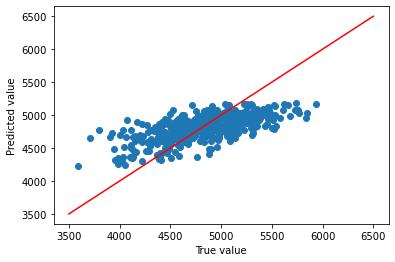

In [538]:
plt.scatter(Y_train,forest_model.predict(X_train))
x=np.linspace(3500,6500,500)
plt.plot(x, x, 'r-')
plt.xlabel('True value')
plt.ylabel('Predicted value')
plt.show()

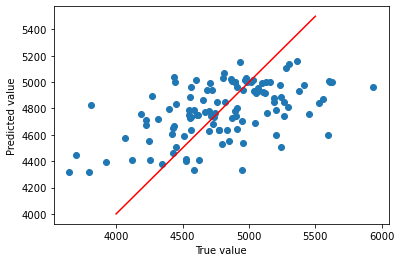

In [539]:
plt.scatter(Y_test,forest_model.predict(X_test))
x=np.linspace(4000,5500,500)
plt.plot(x, x, 'r-')
plt.xlabel('True value')
plt.ylabel('Predicted value')
plt.show()

#### With cross validation

In [540]:
from sklearn.model_selection import GridSearchCV
parameters={'max_depth':[5],
           'max_leaf_nodes':[10],
           'n_estimators':[100]}
forest_model= RandomForestRegressor(random_state = 0)
forest_model_cv=GridSearchCV(forest_model,parameters,cv=5)
forest_model_cv.fit(X_train,Y_train)

GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=0),
             param_grid={'max_depth': [5], 'max_leaf_nodes': [10],
                         'n_estimators': [100]})

In [541]:
print(forest_model_cv.best_params_)
print(forest_model_cv.best_score_)
print('R2:',round(r2_score(Y_train,forest_model_cv.predict(X_train)),2))

{'max_depth': 5, 'max_leaf_nodes': 10, 'n_estimators': 100}
0.1647275342666485
R2: 0.42


In [542]:
Y_pred=forest_model_cv.predict(X_test)
mae = mean_absolute_error(Y_test, Y_pred)
mse = mean_squared_error(Y_test, Y_pred)
r2 = r2_score(Y_test, Y_pred)
print('Mean Absolute Error:', round(mae, 2))
print('Mean Squared Error:', round(mse, 2))
print('R-squared scores:', round(r2, 2))

Mean Absolute Error: 288.54
Mean Squared Error: 134607.41
R-squared scores: 0.27


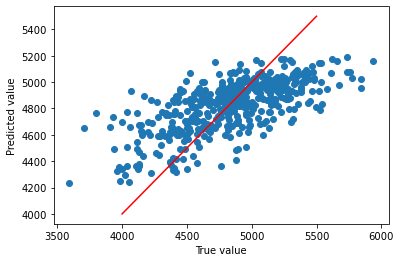

In [543]:
plt.scatter(Y_train,forest_model_cv.predict(X_train))
x=np.linspace(4000,5500,500)
plt.plot(x, x, 'r-')
plt.xlabel('True value')
plt.ylabel('Predicted value')
plt.show()

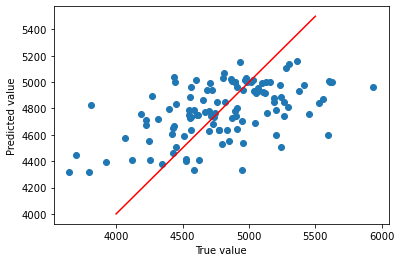

In [544]:
plt.scatter(Y_test,forest_model_cv.predict(X_test))
x=np.linspace(4000,5500,500)
plt.plot(x, x, 'r-')
plt.xlabel('True value')
plt.ylabel('Predicted value')
plt.show()

## XGBoosting

In [14]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
param_grid = {"max_depth":    [4, 5, 6],
              "n_estimators": [500, 600, 700],
              "learning_rate": [0.01, 0.015]}
regressor=xgb.XGBRegressor(eval_metric='rmsle')
regressor_cv = GridSearchCV(regressor, param_grid, cv=5).fit(X_train, Y_train)

In [22]:
regressor=xgb.XGBRegressor(eval_metric='rmsle')
regressor.fit(X_train, Y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric='rmsle', feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [23]:
r2_score(Y_test, regressor.predict(X_test))

0.16746964019099264

In [25]:
r2_score(Y_train, regressor.predict(X_train))

0.9983422412355527

In [15]:
regressor_cv.best_score_

np.float64(0.10647466484584775)

In [16]:
r2_score(Y_test, regressor_cv.predict(X_test))

0.2122680825583303

In [29]:
import matplotlib.pyplot as plt
from xgboost import plot_importance
fig, ax = plt.subplots(figsize=(12,6))
plot_importance(regressor_cv, max_num_features=8,ax=ax)
plt.show()

ValueError: tree must be Booster, XGBModel or dict instance

Error in callback <function _draw_all_if_interactive at 0x1712a36a0> (for post_execute), with arguments args (),kwargs {}:


ValueError: object __array__ method not producing an array

RecursionError: maximum recursion depth exceeded while calling a Python object

<Figure size 1200x600 with 1 Axes>

# With most important variables

In [545]:
features=['bio9','bio18','PC1','PC2','srad','bio3','Mg25']
df_filtered=df[features]
df_filtered.head()

,bio9,bio18,PC1,PC2,srad,bio3,Mg25
2,-0.300000,226,-0.048688,-0.004639,10930.91699,30.079075,5937.667641
3,2.783333,149,-0.010179,-0.026704,10084.16699,28.566383,5936.194976
4,6.133333,171,-0.028367,0.003936,10368.41699,32.532051,5842.619693
5,8.100000,196,-0.022760,-0.003761,10662.33301,32.619976,5841.596886
7,3.500000,255,-0.011897,-0.020086,12462.16699,33.081654,5771.758484


In [370]:
df_filtered.tail()

,bio9,bio18,PC1,PC2,srad,bio3,Mg25
672,22.366667,34,0.001880,0.043584,17056.91602,45.817726,3797.257631
673,4.766667,135,0.005225,-0.035328,10375.91699,28.103914,3704.088675
674,22.466667,54,0.048772,0.054213,15827.75000,36.868687,3700.342494
675,24.350000,42,0.012738,0.048052,16635.16602,39.181816,3644.808362
676,22.916668,47,0.055271,0.050537,16680.75000,39.161850,3589.943197


In [546]:
X=df_filtered.drop(columns=['Mg25'])
Y=df_filtered['Mg25']

In [547]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.25)

In [548]:
Y_train.mean()

4810.900035637647

In [549]:
Y_test.mean()

4839.205322577463

In [550]:
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)
print(X_train[0,:])

[-0.73017917  0.98292574 -1.00703874  0.18678098 -0.4334449   0.05313409]


## Multiple linear regression

In [551]:
from sklearn.linear_model import LinearRegression
lr_model=LinearRegression()
lr_model.fit(X_train, Y_train)
Y_pred=lr_model.predict(X_test)
mae = mean_absolute_error(Y_test, Y_pred)
mse = mean_squared_error(Y_test, Y_pred)
r2 = r2_score(Y_test, Y_pred)
print('Mean Absolute Error:', round(mae, 2))
print('Mean Squared Error:', round(mse, 2))
print('R-squared scores:', round(r2, 2))

Mean Absolute Error: 263.99
Mean Squared Error: 121179.93
R-squared scores: 0.16


In [552]:
r2_score(Y_train,lr_model.predict(X_train))

0.21301384892168473

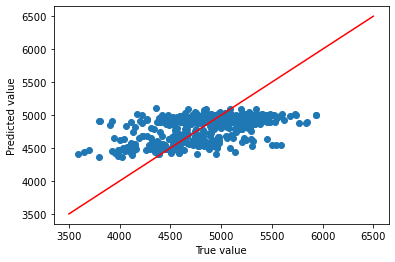

In [553]:
plt.scatter(Y_train,lr_model.predict(X_train))
x=np.linspace(3500,6500,500)
plt.plot(x, x, 'r-')
plt.xlabel('True value')
plt.ylabel('Predicted value')
plt.show()

## Support vector regression

In [380]:
from sklearn.svm import SVR
svr_model = SVR(kernel = 'rbf')
svr_model.fit(X_train, Y_train)
Y_pred=svr_model.predict(X_test)
mae = mean_absolute_error(Y_test, Y_pred)
mse = mean_squared_error(Y_test, Y_pred)
r2 = r2_score(Y_test, Y_pred)
print('Mean Absolute Error:', round(mae, 2))
print('Mean Squared Error:', round(mse, 2))
print('R-squared scores:', round(r2, 2))

Mean Absolute Error: 328.71
Mean Squared Error: 179850.57
R-squared scores: 0.06


## Decision tree

In [381]:
from sklearn.tree import DecisionTreeRegressor
tree_model= DecisionTreeRegressor()
tree_model.fit(X_train, Y_train)
Y_pred=tree_model.predict(X_test)
mae = mean_absolute_error(Y_test, Y_pred)
mse = mean_squared_error(Y_test, Y_pred)
r2 = r2_score(Y_test, Y_pred)
print('Mean Absolute Error:', round(mae, 2))
print('Mean Squared Error:', round(mse, 2))
print('R-squared scores:', round(r2, 2))


Mean Absolute Error: 416.12
Mean Squared Error: 296865.48
R-squared scores: -0.56


## Random forest regression

#### Without cross validation

In [560]:
from sklearn.ensemble import RandomForestRegressor
forest_model= RandomForestRegressor(max_depth=5)
forest_model.fit(X_train, Y_train)
Y_pred=forest_model.predict(X_test)
mae = mean_absolute_error(Y_test, Y_pred)
mse = mean_squared_error(Y_test, Y_pred)
r2 = r2_score(Y_test, Y_pred)
print('Mean Absolute Error:', round(mae, 2))
print('Mean Squared Error:', round(mse, 2))
print('R-squared scores:', round(r2, 2))

Mean Absolute Error: 260.76
Mean Squared Error: 115262.78
R-squared scores: 0.2


In [561]:
forest_model.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'criterion': 'mse',
 'max_depth': 5,
 'max_features': 'auto',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_impurity_split': None,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

In [562]:
r2_score(Y_train,forest_model.predict(X_train))

0.5029120359122121

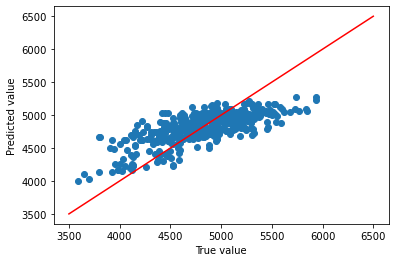

In [563]:
plt.scatter(Y_train,forest_model.predict(X_train))
x=np.linspace(3500,6500,500)
plt.plot(x, x, 'r-')
plt.xlabel('True value')
plt.ylabel('Predicted value')
plt.show()

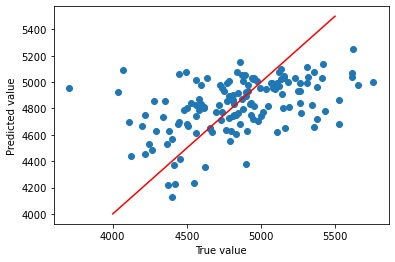

In [564]:
plt.scatter(Y_test,forest_model.predict(X_test))
x=np.linspace(4000,5500,500)
plt.plot(x, x, 'r-')
plt.xlabel('True value')
plt.ylabel('Predicted value')
plt.show()

#### With cross validation

In [565]:
from sklearn.model_selection import GridSearchCV
parameters={'max_depth':[5],
           'max_leaf_nodes':[10],
           'n_estimators':[100]}
forest_model= RandomForestRegressor()
forest_model_cv=GridSearchCV(forest_model,parameters,cv=10)
forest_model_cv.fit(X_train,Y_train)

GridSearchCV(cv=10, estimator=RandomForestRegressor(),
             param_grid={'max_depth': [5], 'max_leaf_nodes': [10],
                         'n_estimators': [100]})

In [566]:
print(forest_model_cv.best_params_)
print(forest_model_cv.best_score_)
print('R2:',round(r2_score(Y_train,forest_model_cv.predict(X_train)),2))

{'max_depth': 5, 'max_leaf_nodes': 10, 'n_estimators': 100}
0.19673050682163237
R2: 0.4


In [567]:
Y_pred=forest_model_cv.predict(X_test)
mae = mean_absolute_error(Y_test, Y_pred)
mse = mean_squared_error(Y_test, Y_pred)
r2 = r2_score(Y_test, Y_pred)
print('Mean Absolute Error:', round(mae, 2))
print('Mean Squared Error:', round(mse, 2))
print('R-squared scores:', round(r2, 2))

Mean Absolute Error: 260.82
Mean Squared Error: 114215.72
R-squared scores: 0.21


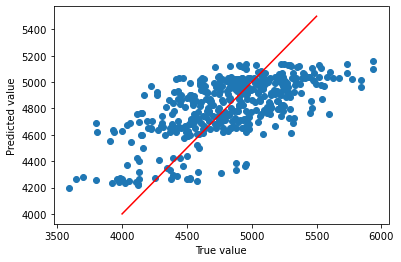

In [568]:
plt.scatter(Y_train,forest_model_cv.predict(X_train))
x=np.linspace(4000,5500,500)
plt.plot(x, x, 'r-')
plt.xlabel('True value')
plt.ylabel('Predicted value')
plt.show()

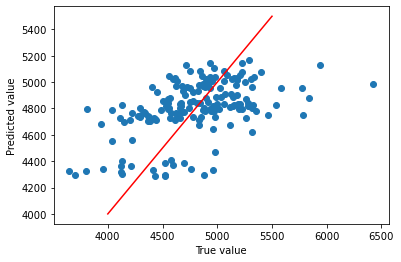

In [391]:
plt.scatter(Y_test,forest_model_cv.predict(X_test))
x=np.linspace(4000,5500,500)
plt.plot(x, x, 'r-')
plt.xlabel('True value')
plt.ylabel('Predicted value')
plt.show()